# Chapter 23 — Train, Validation, and Test Splits

Chapter 22 compared training and validation loss.

This chapter adds a separate test split and explains the distinct role of each dataset partition.

By the end of this chapter, you should be able to:

- explain the purpose of training, validation, and test data;
- split one ordered text stream by position;
- report split indexes, sizes, and realized percentages;
- inspect and visualize boundaries;
- verify reconstruction and non-overlap;
- split a line-based fixture without cutting its lines;
- explain why token-level random shuffling destroys language-model structure; and
- explain why repeated test-set feedback compromises final evaluation.

This chapter prepares data for honest evaluation without introducing a new model.


## Give Each Split One Job

The **training split** supplies counts or learned parameters.

The **validation split** supports development choices such as context length, smoothing strength, tokenizer policy, model size, and later learning-rate settings.

The **test split** is reserved for evaluating the final selected procedure after those choices are settled.

Using all three roles on the same examples can make memorization look like generalization.


## Why Repeated Test Feedback Is Leakage

Suppose several smoothing strengths are tried and the one with the best test loss is selected.

The test data then influenced the model choice, so its score is no longer an untouched estimate of final performance.

Those repeated choices belong on validation data, while the test split should be consulted only at the end of the planned development process.


## Split One Ordered Stream Contiguously

For one continuous corpus, the simplest split preserves order by slicing positions:

```python
training_text = text[:training_end]
validation_text = text[training_end:validation_end]
test_text = text[validation_end:]
```

The slices meet at boundaries without overlapping or reordering tokens.


## Build a Local Ordered Fixture

Thirty short lines provide enough material for visible 80/10/10 sections.


In [1]:
corpus_lines = [
    "the cat sat on the mat.",
    "the cat sat on the rug.",
    "the cat slept on the mat.",
    "the dog sat on the mat.",
    "the dog ran in the yard.",
    "the dog slept on the rug.",
    "the bird sat in the tree.",
    "the bird sang in the tree.",
    "the child sat on the rug.",
    "the child ran in the yard.",
    "the cat ran in the yard.",
    "the dog ate the food.",
    "the cat ate the food.",
    "the bird ate the seed.",
    "the child ate the food.",
    "the cat looked at the dog.",
    "the small cat sat on the mat.",
    "the small dog ran in the yard.",
    "the small bird sang in the tree.",
    "the happy child sat on the rug.",
    "the happy dog slept on the mat.",
    "the dog looked at the cat.",
    "the bird looked at the child.",
    "the child looked at the bird.",
    "the cat watched the bird.",
    "the dog watched the child.",
    "the bird watched the cat.",
    "the child watched the dog.",
    "the small cat ate the food.",
    "the happy bird sang in the tree.",
]

text = "\n".join(corpus_lines)

print(text)
print()
print("Line count:", len(corpus_lines))
print("Character count:", len(text))
print("repr preview:", repr(text[:160]))

the cat sat on the mat.
the cat sat on the rug.
the cat slept on the mat.
the dog sat on the mat.
the dog ran in the yard.
the dog slept on the rug.
the bird sat in the tree.
the bird sang in the tree.
the child sat on the rug.
the child ran in the yard.
the cat ran in the yard.
the dog ate the food.
the cat ate the food.
the bird ate the seed.
the child ate the food.
the cat looked at the dog.
the small cat sat on the mat.
the small dog ran in the yard.
the small bird sang in the tree.
the happy child sat on the rug.
the happy dog slept on the mat.
the dog looked at the cat.
the bird looked at the child.
the child looked at the bird.
the cat watched the bird.
the dog watched the child.
the bird watched the cat.
the child watched the dog.
the small cat ate the food.
the happy bird sang in the tree.

Line count: 30
Character count: 809
repr preview: 'the cat sat on the mat.\nthe cat sat on the rug.\nthe cat slept on the mat.\nthe dog sat on the mat.\nthe dog ran in the yard.\nthe dog sl

## Choose Fractions Deliberately

An 80/10/10 split is a common teaching default rather than a universal law.

The required validation and test sizes depend on corpus scale, diversity, and evaluation goals.


In [2]:
TRAINING_FRACTION = 0.80
VALIDATION_FRACTION = 0.10
TEST_FRACTION = 0.10

fraction_sum = TRAINING_FRACTION + VALIDATION_FRACTION + TEST_FRACTION

print("Fraction sum:", fraction_sum)
assert abs(fraction_sum - 1.0) < 1e-12

Fraction sum: 1.0


## Compute Integer Boundary Positions

String indexes must be integers, so truncation can make realized percentages differ slightly from requested fractions.


In [3]:
total_character_count = len(text)
training_end = int(total_character_count * TRAINING_FRACTION)
validation_end = int(total_character_count * (TRAINING_FRACTION + VALIDATION_FRACTION))

print("Total characters:", total_character_count)
print("Training end index:", training_end)
print("Validation end index:", validation_end)
assert 0 < training_end < validation_end < total_character_count

Total characters: 809
Training end index: 647
Validation end index: 728


## Slice the Three Sections

The half-open slice convention assigns each character to exactly one interval.


In [4]:
training_text = text[:training_end]
validation_text = text[training_end:validation_end]
test_text = text[validation_end:]

print("Training characters:", len(training_text))
print("Validation characters:", len(validation_text))
print("Test characters:", len(test_text))
print("Combined characters:", len(training_text + validation_text + test_text))

assert training_text + validation_text + test_text == text

Training characters: 647
Validation characters: 81
Test characters: 81
Combined characters: 809


## Report Sizes and Realized Percentages

Whole-character boundaries preserve all data while producing percentages close to the requested values.


In [5]:
def print_split_sizes(
    training_text: str,
    validation_text: str,
    test_text: str,
) -> None:
    split_rows = [
        ("training", len(training_text)),
        ("validation", len(validation_text)),
        ("test", len(test_text)),
    ]
    total_size = sum(size for name, size in split_rows)
    if total_size == 0:
        raise ValueError("The combined split size cannot be zero.")

    print("Split       | Characters | Percentage")
    print("-" * 42)
    for split_name, split_size in split_rows:
        percentage = 100 * split_size / total_size
        print(f"{split_name:<11} | {split_size:>10} | {percentage:>9.2f}%")


print_split_sizes(training_text, validation_text, test_text)

Split       | Characters | Percentage
------------------------------------------
training    |        647 |     79.98%
validation  |         81 |     10.01%
test        |         81 |     10.01%


## Inspect Both Boundaries

A boundary preview reveals whether a character-position split cuts a word, sentence, or line.


In [6]:
def print_boundary_preview(
    full_text: str,
    boundary: int,
    label: str,
    context_size: int = 60,
) -> None:
    if not 0 <= boundary <= len(full_text):
        raise ValueError("boundary must be a valid text index.")
    before = full_text[max(0, boundary - context_size) : boundary]
    after = full_text[boundary : min(len(full_text), boundary + context_size)]
    print(label)
    print("  before:", repr(before))
    print("  |SPLIT|")
    print("  after: ", repr(after))


print_boundary_preview(text, training_end, "Training/validation boundary")
print()
print_boundary_preview(text, validation_end, "Validation/test boundary")

Training/validation boundary
  before: 'bird looked at the child.\nthe child looked at the bird.\nthe '
  |SPLIT|
  after:  'cat watched the bird.\nthe dog watched the child.\nthe bird wa'

Validation/test boundary
  before: '\nthe dog watched the child.\nthe bird watched the cat.\nthe ch'
  |SPLIT|
  after:  'ild watched the dog.\nthe small cat ate the food.\nthe happy b'


Position splits can cut linguistic units, which is often acceptable for a very long continuous stream but awkward in a small sentence fixture.


## Verify Coverage With Index Intervals

The intervals `[0, training_end)`, `[training_end, validation_end)`, and `[validation_end, len(text))` are adjacent and non-overlapping.


In [7]:
split_intervals = [
    ("training", 0, training_end),
    ("validation", training_end, validation_end),
    ("test", validation_end, len(text)),
]

print("Split       | Start | End | Size")
print("-" * 37)
for split_name, start, end in split_intervals:
    print(f"{split_name:<11} | {start:>5} | {end:>3} | {end - start:>4}")

assert split_intervals[0][2] == split_intervals[1][1]
assert split_intervals[1][2] == split_intervals[2][1]
assert sum(end - start for name, start, end in split_intervals) == len(text)

Split       | Start | End | Size
-------------------------------------
training    |     0 | 647 |  647
validation  |   647 | 728 |   81
test        |   728 | 809 |   81


## Draw a Compact Text Diagram

The diagram represents relative section widths while preserving a total display width.


In [8]:
def proportional_widths(sizes: list[int], total_width: int) -> list[int]:
    if total_width < len(sizes):
        raise ValueError("total_width must allow at least one cell per split.")
    if any(size <= 0 for size in sizes):
        raise ValueError("Every split size must be positive.")

    total_size = sum(sizes)
    widths = [max(1, int(total_width * size / total_size)) for size in sizes]
    while sum(widths) < total_width:
        largest_gap_index = max(
            range(len(sizes)),
            key=lambda index: total_width * sizes[index] / total_size - widths[index],
        )
        widths[largest_gap_index] += 1
    while sum(widths) > total_width:
        reducible_index = max(
            (index for index, width in enumerate(widths) if width > 1),
            key=widths.__getitem__,
        )
        widths[reducible_index] -= 1
    return widths


def draw_text_split_diagram(
    training_text: str,
    validation_text: str,
    test_text: str,
    total_width: int = 60,
) -> None:
    widths = proportional_widths(
        [len(training_text), len(validation_text), len(test_text)],
        total_width,
    )
    training_width, validation_width, test_width = widths
    print(
        "┌"
        + "─" * training_width
        + "┬"
        + "─" * validation_width
        + "┬"
        + "─" * test_width
        + "┐"
    )
    print(
        "│"
        + "T" * training_width
        + "│"
        + "V" * validation_width
        + "│"
        + "S" * test_width
        + "│"
    )
    print(
        "└"
        + "─" * training_width
        + "┴"
        + "─" * validation_width
        + "┴"
        + "─" * test_width
        + "┘"
    )
    print("T = training, V = validation, S = test")


draw_text_split_diagram(training_text, validation_text, test_text)

┌────────────────────────────────────────────────┬──────┬──────┐
│TTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTT│VVVVVV│SSSSSS│
└────────────────────────────────────────────────┴──────┴──────┘
T = training, V = validation, S = test


## Plot the Contiguous Split

The horizontal bar places each section at its actual character-position interval.


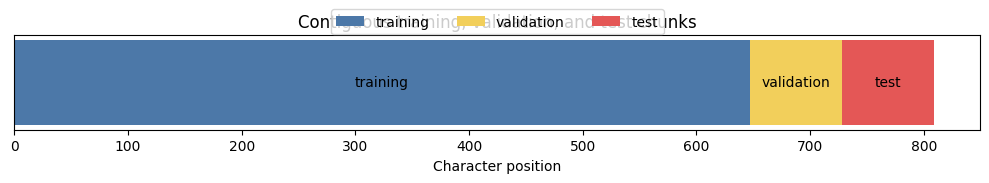

In [9]:
import matplotlib.pyplot as plt  # noqa: I001


split_names = ["training", "validation", "test"]
split_sizes = [len(training_text), len(validation_text), len(test_text)]
split_colors = ["#4C78A8", "#F2CF5B", "#E45756"]
left_edge = 0

plt.figure(figsize=(10, 2.2))
for split_name, split_size, color in zip(
    split_names,
    split_sizes,
    split_colors,
    strict=True,
):
    plt.barh(0, split_size, left=left_edge, color=color, label=split_name)
    plt.text(
        left_edge + split_size / 2,
        0,
        split_name,
        ha="center",
        va="center",
    )
    left_edge += split_size

plt.xlabel("Character position")
plt.yticks([])
plt.title("Contiguous training, validation, and test chunks")
plt.legend(loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.35))
plt.tight_layout()
plt.show()

## Split Small Fixtures at Line Boundaries

Assigning whole lines to contiguous sections avoids cutting the toy sentences while preserving their original order.


In [10]:
def split_lines_contiguously(
    lines: list[str],
    training_fraction: float,
    validation_fraction: float,
) -> tuple[list[str], list[str], list[str]]:
    if not lines:
        raise ValueError("lines cannot be empty.")
    if not 0 < training_fraction < 1:
        raise ValueError("training_fraction must be between 0 and 1.")
    if not 0 < validation_fraction < 1:
        raise ValueError("validation_fraction must be between 0 and 1.")
    if training_fraction + validation_fraction >= 1:
        raise ValueError("Training and validation fractions must sum below 1.")

    training_end = int(len(lines) * training_fraction)
    validation_end = int(len(lines) * (training_fraction + validation_fraction))
    return (
        lines[:training_end],
        lines[training_end:validation_end],
        lines[validation_end:],
    )


training_lines, validation_lines, test_lines = split_lines_contiguously(
    corpus_lines,
    TRAINING_FRACTION,
    VALIDATION_FRACTION,
)

print("Training lines:", len(training_lines))
print("Validation lines:", len(validation_lines))
print("Test lines:", len(test_lines))
assert training_lines + validation_lines + test_lines == corpus_lines

Training lines: 24
Validation lines: 3
Test lines: 3


## Compare Character and Line Splits

Both methods preserve order, but line splitting trades exact character percentages for intact sentence units.


In [11]:
line_training_text = "\n".join(training_lines)
line_validation_text = "\n".join(validation_lines)
line_test_text = "\n".join(test_lines)

print("Character-position split:")
print_split_sizes(training_text, validation_text, test_text)
print()
print("Line-boundary split:")
print_split_sizes(
    line_training_text,
    line_validation_text,
    line_test_text,
)

Character-position split:
Split       | Characters | Percentage
------------------------------------------
training    |        647 |     79.98%
validation  |         81 |     10.01%
test        |         81 |     10.01%

Line-boundary split:
Split       | Characters | Percentage
------------------------------------------
training    |        642 |     79.55%
validation  |         78 |      9.67%
test        |         87 |     10.78%


The line-based strings do not concatenate with inserted separators back to the exact original string unless the separators at split boundaries are accounted for separately.

The line lists themselves reconstruct the original ordered list exactly, which is the correct invariant for this representation.


## Do Not Shuffle Tokens Inside a Sequence

Next-token prediction depends on adjacency, so randomly reordering characters or tokens destroys the task's sequence structure.

The demonstration uses a fixed permutation to keep notebook output deterministic.


In [12]:
original_text = "the cat sat on the mat"
scrambled_positions = [
    4,
    0,
    7,
    2,
    10,
    1,
    13,
    5,
    18,
    3,
    8,
    12,
    6,
    9,
    11,
    14,
    15,
    16,
    17,
    19,
    20,
    21,
]
shuffled_text = "".join(original_text[position] for position in scrambled_positions)

print("Original:", repr(original_text))
print("Shuffled:", repr(shuffled_text))
print("Same character multiset:", sorted(original_text) == sorted(shuffled_text))
assert sorted(original_text) == sorted(shuffled_text)

Original: 'the cat sat on the mat'
Shuffled: 'ct ethna  sota  themat'
Same character multiset: True


The characters are preserved as a multiset, but their predictive ordering is not.


## Compare Adjacent Pairs

Different adjacent pairs show that character shuffling changes the model's training examples rather than merely changing their order.


In [13]:
def adjacent_pairs(text: str, max_pairs: int) -> list[str]:
    if max_pairs < 0:
        raise ValueError("max_pairs cannot be negative.")
    return [
        text[position : position + 2]
        for position in range(min(max_pairs, len(text) - 1))
    ]


original_pairs = adjacent_pairs(original_text, max_pairs=12)
shuffled_pairs = adjacent_pairs(shuffled_text, max_pairs=12)

print("Original pairs:", [repr(pair) for pair in original_pairs])
print("Shuffled pairs:", [repr(pair) for pair in shuffled_pairs])
print("Pair sequences match:", original_pairs == shuffled_pairs)
assert original_pairs != shuffled_pairs

Original pairs: ["'th'", "'he'", "'e '", "' c'", "'ca'", "'at'", "'t '", "' s'", "'sa'", "'at'", "'t '", "' o'"]
Shuffled pairs: ["'ct'", "'t '", "' e'", "'et'", "'th'", "'hn'", "'na'", "'a '", "'  '", "' s'", "'so'", "'ot'"]
Pair sequences match: False


## Whole Documents Are Different Units

If a corpus contains separate documents, assigning whole documents to splits in a shuffled order can be reasonable.

Token order must still remain intact inside each document, and closely related or duplicate documents may need grouping to prevent leakage across splits.

The simple contiguous method in this chapter is most directly suited to one ordered stream.


## Identify Common Data Leaks

- Adding validation or test examples to fitted n-gram counts leaks evaluation outcomes into training.

- Choosing smoothing strength from test loss converts the test set into development data.

- Repeatedly changing a model after viewing test results weakens the final test claim.

- Fitting a learned tokenizer or vocabulary on all splits can leak held-out distribution information when unknown-token behavior is part of evaluation.

Fixed byte vocabularies and externally specified tokenizers require different leakage analysis, so the exact boundary depends on the experimental claim.


## Use Validation for Development Choices

A valid workflow can train several alpha values on training text, compare their validation losses, and select the best alpha.

The chosen model can then be refit according to a prespecified procedure before one final test evaluation.

The validation score is a development result because it influenced the choice, while the untouched test score estimates final held-out performance.


## Define a Reusable Position Splitter

The helper validates fractions, returns all three strings, and exposes both boundary indexes for reproducibility.


In [14]:
def split_text_by_position(
    text: str,
    training_fraction: float,
    validation_fraction: float,
) -> tuple[str, str, str, int, int]:
    if not text:
        raise ValueError("text cannot be empty.")
    if not 0 < training_fraction < 1:
        raise ValueError("training_fraction must be between 0 and 1.")
    if not 0 < validation_fraction < 1:
        raise ValueError("validation_fraction must be between 0 and 1.")
    if training_fraction + validation_fraction >= 1:
        raise ValueError("Training and validation fractions must sum below 1.")

    training_end = int(len(text) * training_fraction)
    validation_end = int(len(text) * (training_fraction + validation_fraction))
    if (
        training_end == 0
        or validation_end == training_end
        or validation_end == len(text)
    ):
        raise ValueError(
            "Fractions and text length must produce three nonempty splits."
        )

    return (
        text[:training_end],
        text[training_end:validation_end],
        text[validation_end:],
        training_end,
        validation_end,
    )


split_result = split_text_by_position(
    text,
    TRAINING_FRACTION,
    VALIDATION_FRACTION,
)
(
    function_training,
    function_validation,
    function_test,
    function_train_end,
    function_validation_end,
) = split_result

assert function_training + function_validation + function_test == text
assert function_train_end == training_end
assert function_validation_end == validation_end
print_split_sizes(function_training, function_validation, function_test)

Split       | Characters | Percentage
------------------------------------------
training    |        647 |     79.98%
validation  |         81 |     10.01%
test        |         81 |     10.01%


## Complete Split Pipeline

The final cell recreates the split, verifies exact reconstruction, and prints both numeric and visual summaries.


In [15]:
(
    final_training,
    final_validation,
    final_test,
    final_training_end,
    final_validation_end,
) = split_text_by_position(
    text,
    training_fraction=0.80,
    validation_fraction=0.10,
)

assert final_training + final_validation + final_test == text
assert len(final_training) > 0
assert len(final_validation) > 0
assert len(final_test) > 0

print("Total characters:", len(text))
print("Training end:", final_training_end)
print("Validation end:", final_validation_end)
print()
print_split_sizes(final_training, final_validation, final_test)
print()
draw_text_split_diagram(final_training, final_validation, final_test)

Total characters: 809
Training end: 647
Validation end: 728

Split       | Characters | Percentage
------------------------------------------
training    |        647 |     79.98%
validation  |         81 |     10.01%
test        |         81 |     10.01%

┌────────────────────────────────────────────────┬──────┬──────┐
│TTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTT│VVVVVV│SSSSSS│
└────────────────────────────────────────────────┴──────┴──────┘
T = training, V = validation, S = test


## Common Mistakes

- Do not evaluate final quality only on data used for fitting.

- Use validation rather than test results for repeated development decisions.

- Preserve token order inside every language-model sequence.

- Inspect boundaries because character-position slicing can cut words or lines.

- Verify that the three position slices reconstruct the exact original stream.

- Report realized split sizes because integer boundaries can shift percentages.

- Group related or duplicate documents when needed to prevent cross-split leakage.


## Takeaways

Training data fits the model, validation data guides development choices, and test data supports final evaluation after those choices are fixed.

Contiguous position slicing provides a simple non-overlapping split for one ordered stream and preserves sequence structure within each section.

Line-boundary or whole-document splitting can be cleaner when the corpus has meaningful independent units.

Randomly shuffling individual characters or tokens destroys the adjacency relationships that define next-token prediction.

The next chapter exponentiates average negative log loss to obtain perplexity, another scale for reporting the same predictive performance.
